# Lab 9.2: CNN Training with Image Augmentation

**Student Name:** Malik Awais Bashir  
**Registration Number:** 22JZELE0474 
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Goal of this Lab
* Import the necessary TensorFlow/Keras modules and model evaluation libraries.
* Specify the paths for the training, validation, and testing image datasets.
* Design and compile a CNN architecture for image classification tasks.
* Train the CNN model and assess its performance through training plots, a confusion matrix, and a classification report.


## Section 1: Library Import and Dataset Paths
This section imports Keras tools, plotting libraries, and evaluation metrics, then defines paths for train, validation, and test image folders.


In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\Computer vision\sectionB\train'
validation_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\Computer vision\sectionB\validation'
test_dir = r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\Computer vision\sectionB\test'

## Section 2: CNN Model Architecture
The following cells create and summarize the convolutional neural network used for classification.


In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

c:\Users\hp\anaconda3\envs\dsp\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [7]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators, Augmentation, and Training
This section prepares image generators, applies rescaling/augmentation, sets checkpoints, and trains the CNN model.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [11]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 5,
                         callbacks = callbacks)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4939 - loss: 1.1526
Epoch 1: val_loss improved from None to 0.61116, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-0001-loss0.61.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.5881 - loss: 0.9550 - val_accuracy: 0.7455 - val_loss: 0.6112
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7229 - loss: 0.6067
Epoch 2: val_loss improved from 0.61116 to 0.54406, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-0002-loss0.54.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.7312 - loss: 0.5795 - val_accuracy: 0.7679 - val_loss: 0.5441
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7842 - loss: 0.4532
Epoch 3: val_loss improved from 0.54406 to 0.39598, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-0003-loss0.40.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7812 - loss: 0.4639 - val_accuracy: 0.8125 - val_loss: 0.3960
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8319 - loss: 0.3895
Epoch 4: val_loss did not improve from 0.39598
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8256 - loss: 0.3974 - val_accuracy: 0.7009 - val_loss: 0.6824
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8382 - loss: 0.3640
Epoch 5: val_loss improved from 0.39598 to 0.29838, saving model to C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-0005-loss0.30.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8356 - loss: 0.3604 - val_accuracy: 0.8482 - val_loss: 0.2984


In [12]:
model_history.history

{'accuracy': [0.5881249904632568,
  0.731249988079071,
  0.78125,
  0.8256250023841858,
  0.8356249928474426],
 'loss': [0.9549655318260193,
  0.5795496106147766,
  0.46390441060066223,
  0.3973967432975769,
  0.3603540062904358],
 'val_accuracy': [0.7455357313156128,
  0.7678571343421936,
  0.8125,
  0.7008928656578064,
  0.8482142686843872],
 'val_loss': [0.6111623644828796,
  0.5440643429756165,
  0.39598336815834045,
  0.6823623776435852,
  0.2983781695365906]}

## Section 4: Model Evaluation
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


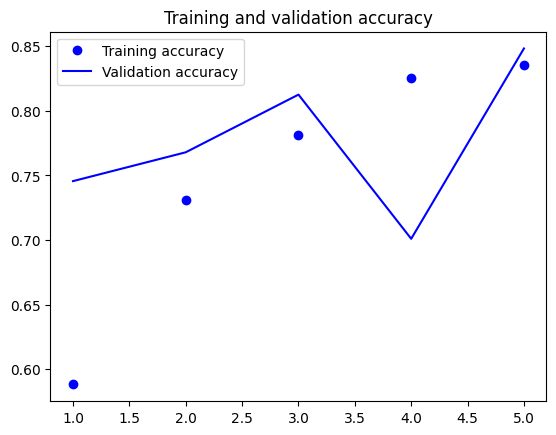

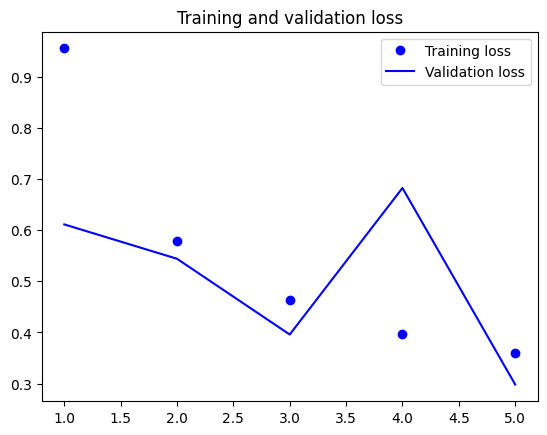

In [13]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\model_Loss.png')

plt.show()

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 948ms/step


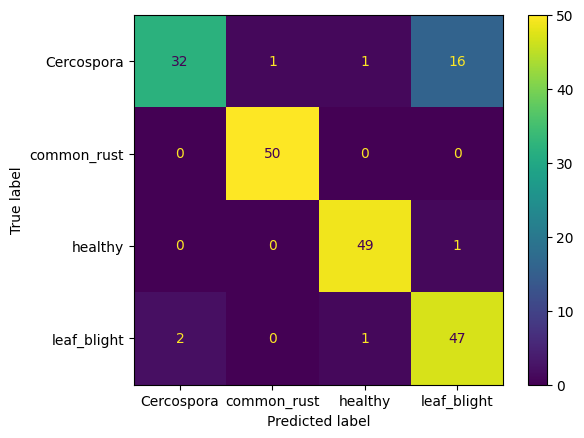

In [18]:
model = load_model(r'C:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 9\\E1-cp-0005-loss0.30.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [19]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.94      0.64      0.76        50
 common_rust       0.98      1.00      0.99        50
     healthy       0.96      0.98      0.97        50
 leaf_blight       0.73      0.94      0.82        50

    accuracy                           0.89       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.89      0.89       200



## Conclusion
* In this lab, a CNN model was trained to classify different corn leaf image categories.
* Image augmentation techniques were applied to enhance the diversity of the training data.
* The prepared dataset was used for model training and validation.
* The model's performance was evaluated using classification metrics and visual analysis tools.
* This lab demonstrated the complete workflow from dataset preparation and augmentation to CNN training and classification evaluation.


